# 🧠 Vector Space Proximity Workshop

## 👥 Group Information

**Group Name:** Group 8  

**Members:**

- Haibo Yuan (Student ID: 9010929)  
- Abdalla Mohamed (Student ID: 9089339)  

---

## 📌 Project Overview

In this workshop, we implement an Information Retrieval (IR) system using vector space models.  

The project includes:

- Text preprocessing (tokenization, normalization, stop-word removal, stemming)
- Vector space representations (incidence matrix, TF, log TF, DF, IDF, TF-IDF)
- Cosine similarity for document retrieval
- Evaluation using metrics such as precision, recall, F1-score, Precision@K, AP, MRR, and Kappa

---

## 🎯 Objective

The goal of this project is to demonstrate that:

> **Relevance is evaluated with respect to the information need, not just keyword matching.**

# 🧠 NLP Foundations Workshop: Vector Space Proximity

### 🔹 Introduction to Vector Space Proximity

A large majority of the data on the Internet is **unstructured**, for example: social media posts, emails, images, videos and audio files.

If we want to **persist** all these media in a database, we may add **metadata** about them, such as file type or creation date timestamp, or we could  **tag** each file, or parts of it, so they are easy to search for. This is because it would be very difficult to identify them based on their low-level (byte) representations.

But, what if we want to make the process fully automated (i.e., remove the need to manually add features, like tags, to each media item)? We need another way to represent the semantics of digital media.

That is the reason why in **Information Retrieval (IR)** and **Natural Language Processing (NLP)**, we often represent documents and queries as **vectors** in a **high-dimensional space**, where:

* Each **dimension** corresponds to a **unique term** in the vocabulary.
* A **document** is represented by a **point** or a **vector** in the space.
* A **vector** is a list of weights (e.g., term frequencies, TF-IDF values) that describe the presence or importance of terms in a document or query.

---

#### 📘 Example 1: "Rich" and "Poor" Axes

![Vector Space Example: "Rich" and "Poor" Axes"](./images/Fig1_CartesianVectorSpace.png)

Suppose our vocabulary only has two terms:

* `"rich"`
* `"poor"`

These two terms define a **2D Cartesian space**:

* The **x-axis** corresponds to the term **"rich"**.
* The **y-axis** corresponds to the term **"poor"**.

Each document is represented as a vector in this space:

* A document with many occurrences of “poor” and none of “rich” lies near the **y-axis**.
* A document that mentions both “rich” and “poor” lies in the **first quadrant**.
* A document with only “rich” is aligned along the **x-axis**.

The **query vector** $q = \{\text{"rich"}, \text{"poor"}\}$ points in the direction of interest for the search engine.

### 🔹 Euclidean Distance and Its Limitations

One might assume we can measure similarity using **Euclidean distance**:

$$
\text{Euclidean}( \vec{q}, \vec{d} ) = \sqrt{ \sum_{i=1}^{n} (q_i - d_i)^2 }
$$

However, this has problems in practice:

* If document $d_2$ contains more occurrences of both “rich” and “poor” than the query, its vector will have a **longer length**.
* As seen in the diagram, even though $d_2$ has strong content overlap with the query $q$, it may still be **further away** in Euclidean terms than unrelated documents like $d_3$.
* This happens because **magnitude dominates**, not direction.

### 🔹 Angle as Similarity → Cosine Similarity

To solve this, we focus on **vector direction**, not length. We measure **angle** between the document and query vectors using **Cosine Similarity**:

$$
\cos(\vec{q}, \vec{d}) = \frac{ \vec{q} \cdot \vec{d} }{ \|\vec{q}\| \cdot \|\vec{d}\| }
= \frac{ \sum_{i=1}^{n} q_i \cdot d_i }{ \sqrt{ \sum_{i=1}^{n} q_i^2 } \cdot \sqrt{ \sum_{i=1}^{n} d_i^2 } }
$$

* This gives us a similarity score from **0 (orthogonal)** to **1 (identical direction)**.
* Longer documents that are semantically aligned still get **high similarity**.

### 🔹 Why Cosine Similarity Works Better

* **Angle** captures **semantic alignment**.
* It is **not affected** by document length or repetition.
* Example: duplicating document $d$ to make $d'$ will increase Euclidean distance — but **cosine similarity remains 1**.

Cosine similarity is at the core of:

* **Search ranking**
* **Embedding-based retrieval**
* **LLM scoring and attention mechanisms**

Sample code:

In [85]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Define the documents and the query
documents = [
    "Ranks of starving poets swell",       # d1
    "Rich poor gap grows",                 # d2
    "Record baseball salaries in 2010"     # d3
]

query = ["rich poor"]                     # q

# Create a CountVectorizer to convert text to term frequency vectors
vectorizer = CountVectorizer()
doc_vectors = vectorizer.fit_transform(documents + query).toarray()

# Separate vectors
doc_matrix = doc_vectors[:3]  # d1, d2, d3
query_vector = doc_vectors[3].reshape(1, -1)  # q

# Compute cosine similarity
cosine_similarities = cosine_similarity(query_vector, doc_matrix).flatten()

# Create a DataFrame to show results
df = pd.DataFrame({
    'Document': ['Doc1', 'Doc2', 'Doc3'],
    'Cosine Similarity with Query': cosine_similarities
})

# Sort for clarity
print("Query: ", query)
df.sort_values(by='Cosine Similarity with Query', ascending=False, inplace=True)
df.reset_index(drop=True, inplace=True)

# Display the result
df


Query:  ['rich poor']


,Document,Cosine Similarity with Query
0,Doc2,0.707107
1,Doc1,0.000000
2,Doc3,0.000000


### Result Interpretation

The cosine similarity results show that **Doc2** is the most relevant document to the query **"rich poor"** because it contains both query terms. **Doc1** and **Doc3** have a similarity score of **0.0** because they do not share the query vocabulary. This confirms that cosine similarity captures directional overlap between the query and document vectors.

### 📘 Example 2: Word Vectors in a Small Corpus

Let's start with a small corpus of just six words, each represented by a vector in 3D space:

```plaintext
CAT     → [ 0.2, -0.4,  0.7]
DOG     → [ 0.6,  0.1,  0.5]
APPLE   → [ 0.8, -0.2, -0.3]
ORANGE  → [ 0.7, -0.1, -0.6]
HAPPY   → [-0.5,  0.9,  0.2]
SAD     → [ 0.4, -0.7, -0.5]
```

Each term is represented by a **vector in 3D space**.

### 🔍 Observations

- Words with **similar meanings** tend to have **similar vector representations**.
  - For example, **APPLE** and **ORANGE** are close in vector space, reflecting their semantic similarity.

- Words with **opposite meanings** tend to have **vectors pointing in opposite directions**.
  - For instance, **HAPPY** and **SAD** have contrasting vectors, indicating their opposing emotional tones.

![3D Visualizationof Word Vectors](./images/Fig2_3DVisualizationWordVectors.png)



### 🔹 Embeddings and Frequency-Based Representations

Vector representations are also called **embeddings**.

One simple family of embeddings is **frequency-based embeddings**. These represent documents numerically using statistics derived from the corpus. A classical example is **TF-IDF**.

TF-IDF highlights words that are frequent within a specific document but rare across the entire corpus. For example, in a document about music, it would emphasize words such as **rap**, **disco**, **pop**, and **rock**, while common pronouns and function words receive low weights.

This workshop stays focused on **Vector Space Proximity** and the use of these vector representations for **matching**, **retrieval**, and **evaluation**.


### 🔹 Transition to Evaluation

Once we represent documents and queries as vectors and compute proximity scores, the next question is:

> **How do we know whether the retrieval system is doing a good job?**

To answer that, we need **evaluation**.


## 🔹 Evaluation of an Information Retrieval System

In Information Retrieval, an **information need** is translated into a **query**.

For example:

- **Information need**: *I want information on whether drinking green tea is more effective than coffee at reducing the risk of heart attacks.*
- **Possible query**: `green tea coffee heart attack effective`

This distinction matters because **relevance is assessed relative to the information need, not the query string itself**.

A document is **relevant** if it addresses the user's real need. A document is **not automatically relevant** just because it contains the words `green`, `tea`, `coffee`, or `heart attack`.

### ✅ Key idea

When evaluating an IR system, we ask:

- Did the system retrieve documents that actually satisfy the information need?
- Not merely: did the system retrieve documents that share words with the query?


### Key Insight

Relevance in Information Retrieval is determined by how well a document satisfies the user's information need, not just by matching keywords in the query.

In [86]:
import pandas as pd

# Benchmark collection for one information need
documents_eval = {
    "Doc1": "A medical review compares green tea and coffee for cardiovascular health and heart attack risk.",
    "Doc2": "Green tea contains antioxidants that may support heart health.",
    "Doc3": "Coffee prices increased this year because of climate conditions affecting crops.",
    "Doc4": "Heart attack warning signs and emergency response guidelines.",
    "Doc5": "A study discusses whether green tea is more effective than coffee in lowering heart attack risk.",
    "Doc6": "The history of tea drinking in East Asia."
}

information_need = (
    "Find information on whether drinking green tea is more effective than coffee "
    "at reducing the risk of heart attacks."
)

query_eval = "green tea coffee heart attack effective"

benchmark_df = pd.DataFrame({
    "Document": list(documents_eval.keys()),
    "Text": list(documents_eval.values())
})

print("Information Need:")
print(information_need)
print("\nQuery:")
print(query_eval)
print("\nBenchmark Collection:")
benchmark_df


Information Need:
Find information on whether drinking green tea is more effective than coffee at reducing the risk of heart attacks.

Query:
green tea coffee heart attack effective

Benchmark Collection:


,Document,Text
0,Doc1,A medical review compares green tea and coffee...
1,Doc2,Green tea contains antioxidants that may suppo...
2,Doc3,Coffee prices increased this year because of c...
3,Doc4,Heart attack warning signs and emergency respo...
4,Doc5,A study discusses whether green tea is more ef...
5,Doc6,The history of tea drinking in East Asia.


### Dataset Description

This benchmark dataset contains six documents related to the information need about green tea, coffee, and heart attack risk. It will be used to evaluate how well the retrieval system identifies relevant documents based on the query.

## 🔹 Evaluating Unranked Results

For **unranked retrieval**, the system returns a **set** of documents, not an ordered list.

To evaluate such a result set, we usually need:

- A **benchmark document collection**
- A **benchmark set of queries**
- A **relevance assessment** for each query-document pair, often created manually by experts

This turns the problem into a **classification-style setup**:

- **Relevant**
- **Nonrelevant**

### Important note

Although **accuracy** is common in machine learning classification, it is **not the main metric in IR**.

Why?

Because in IR, the number of nonrelevant documents is often huge. A system can get high accuracy simply by labeling most documents as nonrelevant, while still failing to retrieve the relevant ones the user actually needs.

So for unranked IR, we focus on measures such as:

- **Precision**
- **Recall**
- **F1-score**

Where:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

$$
F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$


### Key Insight

In Information Retrieval, evaluation focuses on precision and recall rather than accuracy, because the number of nonrelevant documents is usually much larger than relevant ones.

In [87]:
from sklearn.feature_extraction.text import CountVectorizer

# Manual relevance judgments relative to the INFORMATION NEED, not just the query words.
# 1 = relevant, 0 = nonrelevant
relevance_judgments = {
    "Doc1": 1,  # directly compares green tea and coffee for heart attack risk
    "Doc2": 0,  # about green tea and heart health, but does not answer the comparison
    "Doc3": 0,  # contains coffee topic but unrelated to health effectiveness
    "Doc4": 0,  # about heart attacks, but not about green tea vs coffee
    "Doc5": 1,  # directly addresses the information need
    "Doc6": 0   # about tea history, not the medical comparison
}

# A simple UNRANKED retrieval rule:
# retrieve a document if it contains at least one query term
vectorizer_eval = CountVectorizer(binary=True)
X_eval = vectorizer_eval.fit_transform(list(documents_eval.values()) + [query_eval]).toarray()

doc_term_matrix = X_eval[:-1]
query_vector_eval = X_eval[-1]

# Unranked retrieval: retrieve if there is any overlap with the query
retrieved_flags = (doc_term_matrix @ query_vector_eval > 0).astype(int)

results_eval = pd.DataFrame({
    "Document": list(documents_eval.keys()),
    "Retrieved": retrieved_flags,
    "Relevant": [relevance_judgments[d] for d in documents_eval.keys()],
    "Text": list(documents_eval.values())
})

results_eval


,Document,Retrieved,Relevant,Text
0,Doc1,1,1,A medical review compares green tea and coffee...
1,Doc2,1,0,Green tea contains antioxidants that may suppo...
2,Doc3,1,0,Coffee prices increased this year because of c...
3,Doc4,1,0,Heart attack warning signs and emergency respo...
4,Doc5,1,1,A study discusses whether green tea is more ef...
5,Doc6,1,0,The history of tea drinking in East Asia.


### Result Interpretation

The unranked retrieval rule retrieves a document whenever it shares at least one query term with the query. As a result, all six documents are retrieved. However, only **Doc1** and **Doc5** are actually relevant to the information need. This shows that simple keyword overlap can produce many false positives, which reduces precision.

## 🔹 Computing Precision and Recall for the Unranked Result Set

Now we compare the system's retrieved set against the benchmark relevance judgments.

We define:

- **TP (True Positives)**: retrieved and relevant
- **FP (False Positives)**: retrieved but nonrelevant
- **FN (False Negatives)**: not retrieved but relevant
- **TN (True Negatives)**: not retrieved and nonrelevant

In IR, the most informative questions are:

- Of the documents we retrieved, how many were actually useful? → **Precision**
- Of all relevant documents that exist, how many did we find? → **Recall**

This tells us whether the retrieval strategy is too broad, too narrow, or balanced.


In [88]:
# Compute confusion-matrix style counts
tp = int(((results_eval["Retrieved"] == 1) & (results_eval["Relevant"] == 1)).sum())
fp = int(((results_eval["Retrieved"] == 1) & (results_eval["Relevant"] == 0)).sum())
fn = int(((results_eval["Retrieved"] == 0) & (results_eval["Relevant"] == 1)).sum())
tn = int(((results_eval["Retrieved"] == 0) & (results_eval["Relevant"] == 0)).sum())

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy = (tp + tn) / (tp + fp + fn + tn)

summary_df = pd.DataFrame({
    "Metric": ["TP", "FP", "FN", "TN", "Precision", "Recall", "F1", "Accuracy"],
    "Value": [tp, fp, fn, tn, round(precision, 3), round(recall, 3), round(f1, 3), round(accuracy, 3)]
})

summary_df


,Metric,Value
0,TP,2.000
1,FP,4.000
2,FN,0.000
3,TN,0.000
4,Precision,0.333
5,Recall,1.000
6,F1,0.500
7,Accuracy,0.333


### Result Interpretation

The system retrieved all six documents, resulting in **TP = 2** and **FP = 4**, with no false negatives (**FN = 0**). This leads to a **precision of 0.333**, indicating that many retrieved documents are not relevant. However, the **recall is 1.0**, meaning all relevant documents were successfully retrieved. This demonstrates that the retrieval strategy is too broad, achieving high recall at the cost of low precision.

## 🔹 Interpreting the Results

Notice how **accuracy** can look acceptable even when the retrieval behavior is not ideal.

For IR, **precision** and **recall** are more meaningful because they focus on the documents that matter to the user's information need.

### Reflection questions for students

1. Which retrieved documents were **false positives**, and why?
2. Which relevant documents might be missed by a simple lexical query-matching rule?
3. How might **TF-IDF weighting** and **cosine similarity** improve retrieval compared with a simple overlap rule?
4. Why is relevance judged relative to the **information need** rather than the exact query wording?

This sets up the next step in IR evaluation: moving from **unranked result sets** to **ranked retrieval**, where order also matters.


## 🔹 Confusion Matrix for Unranked Retrieval

For **unranked IR evaluation**, we can summarize the result set using a **confusion matrix**.

We compare two things for each document:

- **Did the system retrieve it?**
- **Is it actually relevant to the information need?**

This gives four cases:

- **TP (True Positive)**: retrieved and relevant
- **FP (False Positive)**: retrieved but nonrelevant
- **FN (False Negative)**: not retrieved but relevant
- **TN (True Negative)**: not retrieved and nonrelevant

In IR notation:

- \( P \): total number of relevant documents
- \( N \): total number of nonrelevant documents
- \( \hat{P} \): number of retrieved documents
- \( \hat{N} \): number of not retrieved documents

The confusion matrix helps us connect retrieval behavior to evaluation metrics such as **precision**, **recall**, and **F-measure**.


In [89]:
import pandas as pd

# Build a simple confusion-matrix-style table from the counts already computed
confusion_display = pd.DataFrame(
    [
        [tp, fn, tp + fn],
        [fp, tn, fp + tn],
        [tp + fp, fn + tn, tp + fp + fn + tn]
    ],
    index=["Relevant", "Nonrelevant", "Total"],
    columns=["Retrieved", "Not retrieved", "Total"]
)

print("Confusion Matrix for the Unranked Result Set:")
confusion_display


Confusion Matrix for the Unranked Result Set:


,Retrieved,Not retrieved,Total
Relevant,2,0,2
Nonrelevant,4,0,4
Total,6,0,6


### Result Interpretation

The confusion matrix shows that all documents were retrieved, resulting in **no true negatives (TN = 0)** and **no false negatives (FN = 0)**. While all relevant documents were successfully retrieved (**high recall**), many nonrelevant documents were also retrieved (**high false positives**), which explains the low precision.

## 🔹 Precision–Recall Discussion

A key idea in Information Retrieval is the **tradeoff between precision and recall**.

### Precision

Precision asks:

> Of the documents the system retrieved, how many were actually relevant?

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

High precision means the system returns **few false positives**.

---

### Recall

Recall asks:

> Of all relevant documents in the collection, how many did the system find?

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

High recall means the system returns **few false negatives**.

---

### Why the tradeoff matters

- You can get **high recall** by retrieving many documents, even **all documents**
- But then precision usually drops, because many retrieved documents are nonrelevant
- In a good IR system, as the number of retrieved documents increases, **recall tends to go up** while **precision often goes down**

---

### F-Measure

To balance precision and recall, we often use the **F-measure** (harmonic mean):

$$
F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

The harmonic mean is used because it penalizes systems that do well on one metric but poorly on the other.

### Key interpretation

- **High precision, low recall**: the system is conservative and misses relevant documents
- **Low precision, high recall**: the system retrieves many relevant documents, but also too many irrelevant ones
- **Balanced F1**: the system has a good compromise between the two


Ranked prefixes and their precision/recall values:


,Document,OverlapScore,Relevant
0,Doc5,6,1
1,Doc1,5,1
2,Doc2,3,0
3,Doc4,2,0
4,Doc3,1,0
5,Doc6,1,0


,k,Precision@k,Recall@k
0,1,1.000,0.5
1,2,1.000,1.0
2,3,0.667,1.0
3,4,0.500,1.0
4,5,0.400,1.0
5,6,0.333,1.0


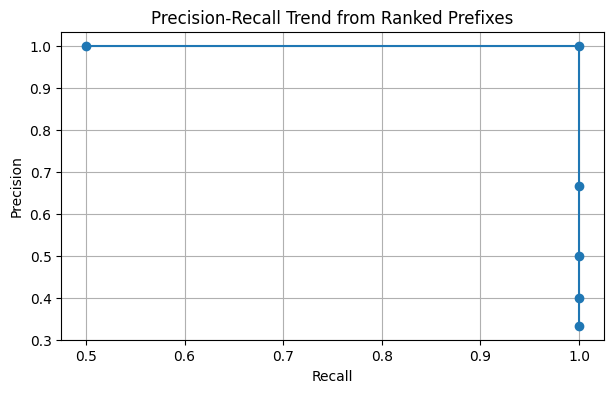

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Precision-recall style thought experiment:
# rank documents by simple query overlap score, then evaluate prefixes of the ranked list

overlap_scores = (doc_term_matrix @ query_vector_eval).astype(int)

ranked_df = pd.DataFrame({
    "Document": list(documents_eval.keys()),
    "OverlapScore": overlap_scores,
    "Relevant": [relevance_judgments[d] for d in documents_eval.keys()]
}).sort_values(by=["OverlapScore", "Document"], ascending=[False, True]).reset_index(drop=True)

precision_values = []
recall_values = []
k_values = []

num_relevant = ranked_df["Relevant"].sum()
tp_running = 0
fp_running = 0

for k in range(1, len(ranked_df) + 1):
    current_rel = ranked_df.loc[k - 1, "Relevant"]
    if current_rel == 1:
        tp_running += 1
    else:
        fp_running += 1

    precision_k = tp_running / (tp_running + fp_running)
    recall_k = tp_running / num_relevant if num_relevant > 0 else 0

    k_values.append(k)
    precision_values.append(precision_k)
    recall_values.append(recall_k)

pr_table = pd.DataFrame({
    "k": k_values,
    "Precision@k": np.round(precision_values, 3),
    "Recall@k": np.round(recall_values, 3)
})

print("Ranked prefixes and their precision/recall values:")
display(ranked_df)
display(pr_table)

plt.figure(figsize=(7, 4))
plt.plot(recall_values, precision_values, marker="o")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Trend from Ranked Prefixes")
plt.grid(True)
plt.show()


### Result Interpretation

The ranked retrieval results show that the two truly relevant documents (**Doc5** and **Doc1**) appear at the top of the ranking. This gives **Precision@1 = 1.0** and **Precision@2 = 1.0**, while recall reaches **1.0** by **k = 2**. After that point, additional nonrelevant documents reduce precision, showing that good ranking places relevant documents early in the result list.

## 🔹 What Students Should Notice

From the confusion matrix and the precision–recall discussion, students should observe that:

1. **Evaluation is tied to the information need**, not just query-term overlap.
2. A system can retrieve many documents and improve **recall**, but this may reduce **precision**.
3. The confusion matrix gives a compact way to understand retrieval outcomes.
4. Precision, recall, and F1 are more informative for IR than plain accuracy.
5. This also prepares us for **ranked retrieval evaluation**, where the order of results matters.

This completes the bridge from **vector representations and proximity** to **practical IR evaluation**.


## 🔹 Interpolated Precision

A retrieval system can return **any number of results**, so the raw precision values observed along a ranking can fluctuate up and down.

To make the precision–recall curve easier to interpret, we use **interpolated precision**.

At a recall level \( r \), the interpolated precision is defined as:

$$
p_{\mathrm{interp}}(r) = \max_{r' \ge r} p(r')
$$

This means:

- look at the current recall level \( r \)
- look to the **right** on the precision–recall curve, at all recall levels \( r' \ge r \)
- take the **highest precision** found there

### Why do this?

It smooths the curve and answers the question:

> "At this recall level or beyond, what is the best precision the system achieves?"

This produces a non-increasing interpolated precision curve, which is often easier to compare across systems.


Raw vs. Interpolated Precision:


,Recall,Raw Precision,Interpolated Precision
0,0.5,1.000,1.000
1,1.0,1.000,1.000
2,1.0,0.667,0.667
3,1.0,0.500,0.500
4,1.0,0.400,0.400
5,1.0,0.333,0.333


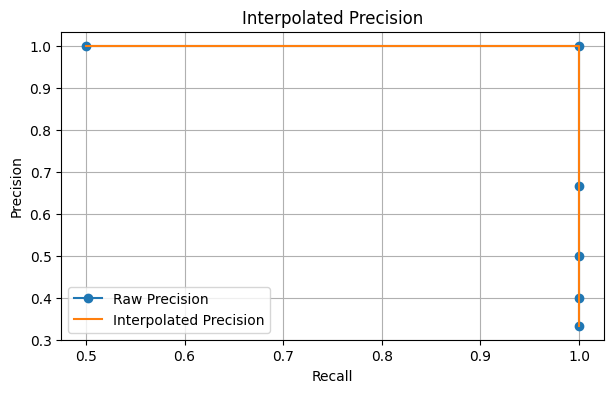

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use the recall_values and precision_values computed earlier from ranked prefixes
interp_precision = np.maximum.accumulate(precision_values[::-1])[::-1]

interp_df = pd.DataFrame({
    "Recall": np.round(recall_values, 3),
    "Raw Precision": np.round(precision_values, 3),
    "Interpolated Precision": np.round(interp_precision, 3)
})

print("Raw vs. Interpolated Precision:")
display(interp_df)

plt.figure(figsize=(7, 4))
plt.plot(recall_values, precision_values, marker="o", label="Raw Precision")
plt.step(recall_values, interp_precision, where="post", label="Interpolated Precision")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Interpolated Precision")
plt.grid(True)
plt.legend()
plt.show()


### Result Interpretation

The interpolated precision values smooth the precision-recall trend by keeping the maximum precision observed at each recall level or beyond. In this example, the interpolated values remain close to the raw precision values because the ranking starts with the two relevant documents and then gradually adds nonrelevant ones. This makes the curve easier to interpret while preserving the overall retrieval behavior.

## 🔹 Precision@K and Recall@K

In ranked retrieval, we often care most about the **top of the ranking**.

So instead of evaluating the whole ranked list, we set a threshold \( K \) and only look at the top \( K \) documents.

### Precision@K

Precision@K measures the proportion of relevant documents among the top \( K \) results:

$$
P@K = \frac{\# \text{ relevant documents in top } K}{K}
$$

### Recall@K

Recall@K measures how many of all relevant documents have been found in the top \( K \) results:

$$
R@K = \frac{\# \text{ relevant documents in top } K}{\# \text{ total relevant documents in the collection}}
$$

### Key idea

- **Precision@K** ignores all documents ranked lower than \( K \)
- This is useful when users usually look at only the first few results
- Recall@K complements it by showing how much of the relevant material has already been found


In [92]:
# Example using the ranked list already created earlier
p_at_k_rows = []
total_relevant = ranked_df["Relevant"].sum()
relevant_so_far = 0

for k in range(1, len(ranked_df) + 1):
    if ranked_df.loc[k - 1, "Relevant"] == 1:
        relevant_so_far += 1
    p_at_k = relevant_so_far / k
    r_at_k = relevant_so_far / total_relevant if total_relevant > 0 else 0
    p_at_k_rows.append([k, ranked_df.loc[k - 1, "Document"], ranked_df.loc[k - 1, "Relevant"], round(p_at_k, 3), round(r_at_k, 3)])

p_at_k_df = pd.DataFrame(
    p_at_k_rows,
    columns=["K", "Document at Rank K", "Relevant?", "Precision@K", "Recall@K"]
)

print("Precision@K and Recall@K by rank position:")
p_at_k_df


Precision@K and Recall@K by rank position:


,K,Document at Rank K,Relevant?,Precision@K,Recall@K
0,1,Doc5,1,1.000,0.5
1,2,Doc1,1,1.000,1.0
2,3,Doc2,0,0.667,1.0
3,4,Doc4,0,0.500,1.0
4,5,Doc3,0,0.400,1.0
5,6,Doc6,0,0.333,1.0


### Result Interpretation

The results show that the first two ranked documents are both relevant, giving **Precision@1 = 1.0** and **Precision@2 = 1.0**, while recall reaches **1.0** at **K = 2**. As more nonrelevant documents are included in the ranking, precision gradually decreases, while recall remains unchanged. This demonstrates that the system ranks relevant documents at the top, which is desirable in ranked retrieval.

## 🔹 Average Precision (AP)

**Average Precision (AP)** summarizes the ranking quality for a **single query**.

The idea is:

1. Find every rank position where a **relevant** document appears
2. Compute **Precision@K** at each of those positions
3. Average those precision values

If the relevant documents appear early in the ranking, AP will be higher.

A common formula is:

$$
AP = \frac{1}{R} \sum_{k=1}^{n} P@k \cdot \mathrm{rel}(k)
$$

Where:

- \( R \) is the number of relevant documents for the query
- \( P@k \) is precision at rank \( k \)
- \( \mathrm{rel}(k) = 1 \) if the document at rank \( k \) is relevant, otherwise \( 0 \)

### Interpretation

AP rewards systems that place relevant documents **near the top** of the ranking, not just somewhere in the list.


In [93]:
# Compute Average Precision (AP) for the current ranked list
relevance_list = ranked_df["Relevant"].tolist()

precision_at_relevant = []
relevant_seen = 0

for k, rel in enumerate(relevance_list, start=1):
    if rel == 1:
        relevant_seen += 1
        precision_k = relevant_seen / k
        precision_at_relevant.append(precision_k)

average_precision = sum(precision_at_relevant) / total_relevant if total_relevant > 0 else 0

ap_details_df = pd.DataFrame({
    "Rank": list(range(1, len(relevance_list) + 1)),
    "Document": ranked_df["Document"],
    "Relevant": relevance_list,
    "Precision@K": [round((sum(relevance_list[:k]) / k), 3) for k in range(1, len(relevance_list) + 1)]
})

print("Average Precision (AP) details:")
display(ap_details_df)
print(f"\nAverage Precision (AP): {average_precision:.3f}")


Average Precision (AP) details:


,Rank,Document,Relevant,Precision@K
0,1,Doc5,1,1.000
1,2,Doc1,1,1.000
2,3,Doc2,0,0.667
3,4,Doc4,0,0.500
4,5,Doc3,0,0.400
5,6,Doc6,0,0.333



Average Precision (AP): 1.000


### Result Interpretation

The Average Precision (AP) is **1.000**, indicating a perfect ranking for this query. Both relevant documents (**Doc5** and **Doc1**) appear at the top positions (ranks 1 and 2), each with a precision of **1.0**. Since AP averages the precision values at the ranks where relevant documents occur, placing all relevant documents early in the ranking results in the highest possible AP score.

## 🔹 Mean Reciprocal Rank (MRR)

**Mean Reciprocal Rank (MRR)** is useful when the user mainly wants to find **one good relevant document quickly**.

For a query \( q_j \), let \( R_j \) be the rank of the **first relevant document**.

The reciprocal rank for that query is:

$$
RR_j = \frac{1}{R_j}
$$

Over multiple queries, Mean Reciprocal Rank is:

$$
MRR = \frac{1}{|Q|} \sum_{j=1}^{|Q|} \frac{1}{R_j}
$$

Where:

- \( |Q| \) is the number of queries
- \( R_j \) is the rank of the first relevant result for query \( j \)

### Interpretation

- If the first relevant result is ranked **1st**, reciprocal rank = \( 1.0 \)
- If the first relevant result is ranked **2nd**, reciprocal rank = \( 0.5 \)
- If it is ranked **5th**, reciprocal rank = \( 0.2 \)

MRR is especially appropriate when the user's goal is satisfied by seeing just **one relevant answer near the top**.


In [94]:
# Demonstrate Reciprocal Rank and Mean Reciprocal Rank (MRR) on a few example rankings
example_rankings = {
    "Query1": [1, 0, 0, 0, 0],   # first relevant at rank 1
    "Query2": [0, 1, 0, 1, 0],   # first relevant at rank 2
    "Query3": [0, 0, 0, 1, 0],   # first relevant at rank 4
    "Query4": [0, 0, 0, 0, 0]    # no relevant result found
}

mrr_rows = []
rr_values = []

for query_name, rels in example_rankings.items():
    first_relevant_rank = None
    for rank, rel in enumerate(rels, start=1):
        if rel == 1:
            first_relevant_rank = rank
            break

    rr = 1 / first_relevant_rank if first_relevant_rank is not None else 0
    rr_values.append(rr)
    mrr_rows.append([query_name, rels, first_relevant_rank, round(rr, 3)])

mrr_df = pd.DataFrame(mrr_rows, columns=["Query", "Ranking Relevance Pattern", "First Relevant Rank", "Reciprocal Rank"])
mrr_value = sum(rr_values) / len(rr_values) if rr_values else 0

print("Mean Reciprocal Rank (MRR) example:")
display(mrr_df)
print(f"\nMRR across the example queries: {mrr_value:.3f}")


Mean Reciprocal Rank (MRR) example:


,Query,Ranking Relevance Pattern,First Relevant Rank,Reciprocal Rank
0,Query1,"[1, 0, 0, 0, 0]",1.0,1.00
1,Query2,"[0, 1, 0, 1, 0]",2.0,0.50
2,Query3,"[0, 0, 0, 1, 0]",4.0,0.25
3,Query4,"[0, 0, 0, 0, 0]",NaN,0.00



MRR across the example queries: 0.438


### Result Interpretation

The Mean Reciprocal Rank (MRR) is **0.438**, which reflects how quickly the first relevant document appears across multiple queries. Query1 achieves the best result with the first relevant document at rank 1 (RR = 1.0), while Query2 and Query3 have lower reciprocal ranks due to later relevant results. Query4 has no relevant documents retrieved, resulting in an RR of 0. This demonstrates that MRR emphasizes early retrieval of relevant documents.

## 🔹 What These Ranked Metrics Add

These ranked evaluation measures help students move beyond simple unranked retrieval:

- **Interpolated Precision** smooths the precision–recall curve
- **Precision@K** focuses on the top of the ranking
- **Average Precision (AP)** rewards rankings that place relevant documents early
- **Mean Reciprocal Rank (MRR)** focuses on how quickly the first useful result appears

Together, these measures connect naturally to **vector space retrieval**, because once documents are ranked by proximity or similarity, we need ways to evaluate **how good that ranking is**.


## 🔹 Creating Test Collections for IR Evaluation

When experts create **test collections** for Information Retrieval, they build the benchmark needed to evaluate a retrieval system.

A typical test collection contains:

- a **document collection**
- a **set of queries or information needs**
- a set of **relevance judgments** indicating whether each document is relevant or nonrelevant for each query

### Why agreement matters

In practice, human judges do **not** agree 100% of the time.

Two experts may disagree about whether a document is relevant, especially when relevance is subjective, partial, or context-dependent.

Because of this, IR evaluation often measures **inter-judge agreement**.

A common measure is **Cohen's Kappa**, which adjusts the observed agreement by subtracting the agreement that could have happened **by chance**.

$$
\kappa = \frac{P(A) - P(E)}{1 - P(E)}
$$

Where:

- \( P(A) \) is the **observed agreement**
- \( P(E) \) is the **expected agreement by chance**

### Interpretation

- \( \kappa > 0.8 \): strong agreement
- \( 0.67 < \kappa \le 0.8 \): tentative but useful agreement
- lower values suggest the judgments may need review

For more than two judges, a common classroom simplification is to compute the **average pairwise kappa**.


In [95]:
import pandas as pd

# Example: two judges label the same 10 documents for one query
judgments_df = pd.DataFrame({
    "Document": [f"Doc{i}" for i in range(1, 11)],
    "Judge1":   [1, 1, 0, 1, 0, 0, 1, 0, 1, 0],  # 1 = Relevant, 0 = Nonrelevant
    "Judge2":   [1, 0, 0, 1, 0, 0, 1, 1, 1, 0]
})

judgments_df["Agreement"] = (judgments_df["Judge1"] == judgments_df["Judge2"]).astype(int)

print("Example relevance judgments from two judges:")
judgments_df


Example relevance judgments from two judges:


,Document,Judge1,Judge2,Agreement
0,Doc1,1,1,1
1,Doc2,1,0,0
2,Doc3,0,0,1
3,Doc4,1,1,1
4,Doc5,0,0,1
5,Doc6,0,0,1
6,Doc7,1,1,1
7,Doc8,0,1,0
8,Doc9,1,1,1
9,Doc10,0,0,1


### Result Interpretation

The table shows how two judges labeled the same set of documents and whether they agreed on each judgment. Most documents have agreement, but there are some disagreements (e.g., Doc2 and Doc8), which highlights the need for measuring inter-judge reliability.

## 🔹 Kappa Measure Example

To compute **Cohen's Kappa**, we need two quantities:

### 1. Observed agreement \( P(A) \)

This is the proportion of items for which the judges gave the same label.

### 2. Expected agreement \( P(E) \)

This is the agreement we would expect **by chance**, based on the overall label frequencies of each judge.

If the two labels are **Relevant** and **Nonrelevant**, then:

$$
P(E) = P(\text{Relevant}) + P(\text{Nonrelevant})
$$

More explicitly:

$$
P(E) =
\left(\frac{\text{Judge1 relevant}}{N} \times \frac{\text{Judge2 relevant}}{N}\right)
+
\left(\frac{\text{Judge1 nonrelevant}}{N} \times \frac{\text{Judge2 nonrelevant}}{N}\right)
$$

Then:

$$
\kappa = \frac{P(A) - P(E)}{1 - P(E)}
$$

Kappa tells us how much better the judges agree than would be expected by random coincidence alone.


In [96]:
# Build the 2x2 agreement table
agreement_table = pd.crosstab(
    judgments_df["Judge1"].map({1: "Relevant", 0: "Nonrelevant"}),
    judgments_df["Judge2"].map({1: "Relevant", 0: "Nonrelevant"}),
    rownames=["Judge 1"],
    colnames=["Judge 2"],
    dropna=False
)

# Ensure both labels exist as rows/columns
for label in ["Relevant", "Nonrelevant"]:
    if label not in agreement_table.index:
        agreement_table.loc[label] = 0
    if label not in agreement_table.columns:
        agreement_table[label] = 0

agreement_table = agreement_table.loc[["Relevant", "Nonrelevant"], ["Relevant", "Nonrelevant"]]

# Counts
a = agreement_table.loc["Relevant", "Relevant"]
b = agreement_table.loc["Relevant", "Nonrelevant"]
c = agreement_table.loc["Nonrelevant", "Relevant"]
d = agreement_table.loc["Nonrelevant", "Nonrelevant"]
N = a + b + c + d

# Observed agreement
P_A = (a + d) / N

# Expected agreement by chance
p_rel_j1 = (a + b) / N
p_non_j1 = (c + d) / N
p_rel_j2 = (a + c) / N
p_non_j2 = (b + d) / N

P_E = (p_rel_j1 * p_rel_j2) + (p_non_j1 * p_non_j2)

kappa = (P_A - P_E) / (1 - P_E) if (1 - P_E) != 0 else 0

print("Agreement Table:")
display(agreement_table)

kappa_summary = pd.DataFrame({
    "Quantity": ["Observed Agreement P(A)", "Expected Agreement P(E)", "Kappa"],
    "Value": [round(P_A, 3), round(P_E, 3), round(kappa, 3)]
})

print("\nKappa Summary:")
kappa_summary


Agreement Table:


Judge 2,Relevant,Nonrelevant
Judge 1,,
Relevant,4,1
Nonrelevant,1,4



Kappa Summary:


,Quantity,Value
0,Observed Agreement P(A),0.8
1,Expected Agreement P(E),0.5
2,Kappa,0.6


### Result Interpretation

The observed agreement between the two judges is **P(A) = 0.800**, indicating that they agree on most document labels. The expected agreement by chance is **P(E) = 0.500**, meaning that some agreement could occur randomly. The resulting **Cohen’s Kappa is 0.600**, which suggests a moderate level of agreement between the judges. This indicates that the relevance judgments are reasonably consistent, but there is still some disagreement that could affect evaluation quality.

## 🔹 Worked Kappa Example from a 2×2 Table

Suppose two judges produced the following counts over **400 documents**:

- 300 documents labeled **Relevant** by both judges
- 20 documents labeled **Relevant** by Judge 1 but **Nonrelevant** by Judge 2
- 10 documents labeled **Nonrelevant** by Judge 1 but **Relevant** by Judge 2
- 70 documents labeled **Nonrelevant** by both judges

This is exactly the kind of table shown in the slides.

From this table we can compute:

- \( P(A) \): proportion of exact agreement
- \( P(E) \): chance agreement from marginal label proportions
- \( \kappa \): agreement adjusted for chance


In [97]:
# Example taken directly from the slide-style counts
a, b, c, d = 300, 20, 10, 70
N = a + b + c + d

example_table = pd.DataFrame(
    [[a, b, a + b],
     [c, d, c + d],
     [a + c, b + d, N]],
    index=["Judge1 Relevant", "Judge1 Nonrelevant", "Total"],
    columns=["Judge2 Relevant", "Judge2 Nonrelevant", "Total"]
)

P_A_ex = (a + d) / N

p_rel_j1_ex = (a + b) / N
p_non_j1_ex = (c + d) / N
p_rel_j2_ex = (a + c) / N
p_non_j2_ex = (b + d) / N

P_E_ex = (p_rel_j1_ex * p_rel_j2_ex) + (p_non_j1_ex * p_non_j2_ex)
kappa_ex = (P_A_ex - P_E_ex) / (1 - P_E_ex)

print("Worked 2x2 Kappa Table:")
display(example_table)

example_summary = pd.DataFrame({
    "Quantity": ["P(A)", "P(E)", "Kappa"],
    "Value": [round(P_A_ex, 3), round(P_E_ex, 3), round(kappa_ex, 3)]
})

print("\nWorked Example Summary:")
display(example_summary)

if kappa_ex > 0.8:
    interpretation = "Strong agreement"
elif kappa_ex > 0.67:
    interpretation = "Tentative but useful agreement"
else:
    interpretation = "Agreement may be too weak for confident conclusions"

print("Interpretation:", interpretation)


Worked 2x2 Kappa Table:


,Judge2 Relevant,Judge2 Nonrelevant,Total
Judge1 Relevant,300,20,320
Judge1 Nonrelevant,10,70,80
Total,310,90,400



Worked Example Summary:


,Quantity,Value
0,P(A),0.925
1,P(E),0.665
2,Kappa,0.776


Interpretation: Tentative but useful agreement


### Result Interpretation

In this worked example, the observed agreement is **P(A) = 0.925**, which means the two judges agree on most of the 400 documents. The expected agreement by chance is **P(E) = 0.665**, and the resulting **Kappa = 0.776**. This falls into the **tentative but useful agreement** range, showing that the judges are substantially consistent, although the agreement is not perfect.

## 🔹 Why This Matters for IR Evaluation

A retrieval system can only be evaluated well if the **test collection** is trustworthy.

That means:

- the documents are appropriate
- the information needs are clear
- the relevance judgments are reasonably consistent

Kappa does **not** say the judges are perfect.  
It tells us whether their agreement is **better than chance**.

This is important because many IR metrics—precision, recall, AP, MRR, and MAP—depend on the quality of the underlying relevance labels.


## 🔹 Final Student Challenge: End-to-End Vector Space Proximity Project

Now that you have studied:

- term-document incidence matrices
- term frequency
- log-frequency weighting
- document frequency
- inverse document frequency
- TF-IDF weighting
- cosine similarity
- unranked and ranked IR evaluation
- precision, recall, F1, AP, MRR, and Kappa

you will now apply **all of these concepts** to a **large real corpus**.

### 🎯 Challenge Goal

Build a mini Information Retrieval system over a **large downloaded corpus** and evaluate it.

Your system must:

1. download or load a large corpus
2. preprocess and normalize the text
3. build vector representations
4. retrieve documents for user queries
5. evaluate the retrieval results using the metrics from this workshop

### Corpus Requirement

Use a corpus that is clearly larger than the small examples used in class.

Examples:

- a large set of Wikipedia articles
- the 20 Newsgroups dataset
- a Project Gutenberg collection
- a news dataset
- a government open-data text collection

Your collection should be large enough to make the retrieval and evaluation steps meaningful.


## 🔹 Student Tasks

### Part A — Build the Corpus

Download a large corpus and create a document collection.

You must report:

- corpus source
- number of documents
- approximate vocabulary size
- a short description of the domain

### Part B — Build the Retrieval Pipeline

Implement the following:

1. **Tokenizer**
2. **Normalization**
3. **Stop-word removal**
4. **Stemming or lemmatization**
5. **Term-document incidence matrix**
6. **Term frequency**
7. **Log-frequency weighting**
8. **Document frequency**
9. **Inverse document frequency**
10. **TF-IDF weighting**
11. **Cosine similarity retrieval**

### Part C — Querying

Create at least **5 information needs** and convert each into one or more queries.

For each query:

- retrieve the top documents
- explain why the retrieved documents are or are not relevant
- compare retrieval using at least **two different representations**, such as:
  - binary incidence
  - raw TF
  - TF-IDF

### Part D — Evaluation

For at least **3 queries**, create relevance judgments and compute:

- confusion matrix
- precision
- recall
- F1-score
- Precision@K
- Average Precision (AP)
- Mean Reciprocal Rank (MRR)

If two teammates judge the same query-document pairs, also compute **Cohen's Kappa**.


In [98]:
# Suggested starter: download a large benchmark corpus
from sklearn.datasets import fetch_20newsgroups
import pandas as pd

newsgroups = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)

documents = newsgroups.data
targets = newsgroups.target
target_names = newsgroups.target_names

corpus_df = pd.DataFrame({
    "DocumentID": range(len(documents)),
    "Text": documents,
    "CategoryID": targets
})

corpus_df["Category"] = corpus_df["CategoryID"].apply(lambda x: target_names[x])

print("Number of documents:", len(corpus_df))
print("Sample categories:", corpus_df["Category"].unique()[:10])
corpus_df.head()


Number of documents: 11314
Sample categories: <StringArray>
[               'rec.autos',    'comp.sys.mac.hardware',
            'comp.graphics',                'sci.space',
       'talk.politics.guns',                  'sci.med',
 'comp.sys.ibm.pc.hardware',  'comp.os.ms-windows.misc',
          'rec.motorcycles',       'talk.religion.misc']
Length: 10, dtype: str


,DocumentID,Text,CategoryID,Category
0,0,I was wondering if anyone out there could enli...,7,rec.autos
1,1,A fair number of brave souls who upgraded thei...,4,comp.sys.mac.hardware
2,2,"well folks, my mac plus finally gave up the gh...",4,comp.sys.mac.hardware
3,3,\nDo you have Weitek's address/phone number? ...,1,comp.graphics
4,4,"From article <C5owCB.n3p@world.std.com>, by to...",14,sci.space


### 🔹 Part A — Corpus Description

In [99]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd
import re

# Load a large benchmark corpus
newsgroups = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)

documents = newsgroups.data
targets = newsgroups.target
target_names = newsgroups.target_names

# Build a DataFrame
corpus_df = pd.DataFrame({
    "DocumentID": range(len(documents)),
    "Text": documents,
    "CategoryID": targets
})

corpus_df["Category"] = corpus_df["CategoryID"].apply(lambda x: target_names[x])

# Approximate vocabulary size
all_text = " ".join(corpus_df["Text"].fillna("").astype(str))
tokens = re.findall(r"\b[a-zA-Z]+\b", all_text.lower())
vocab_size = len(set(tokens))

print("Corpus Source: 20 Newsgroups dataset (scikit-learn)")
print("Number of documents:", len(corpus_df))
print("Approximate vocabulary size:", vocab_size)
print("Number of categories:", len(target_names))
print("\nSample categories:")
print(target_names[:10])

corpus_df.head()

Corpus Source: 20 Newsgroups dataset (scikit-learn)
Number of documents: 11314
Approximate vocabulary size: 67757
Number of categories: 20

Sample categories:
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball']


,DocumentID,Text,CategoryID,Category
0,0,I was wondering if anyone out there could enli...,7,rec.autos
1,1,A fair number of brave souls who upgraded thei...,4,comp.sys.mac.hardware
2,2,"well folks, my mac plus finally gave up the gh...",4,comp.sys.mac.hardware
3,3,\nDo you have Weitek's address/phone number? ...,1,comp.graphics
4,4,"From article <C5owCB.n3p@world.std.com>, by to...",14,sci.space


### Corpus Description

For this project, I selected the **20 Newsgroups dataset** provided by **scikit-learn**. It is a large text corpus containing documents from multiple discussion groups across different domains such as technology, politics, science, religion, and recreation.

The corpus contains **thousands of documents**, which makes it suitable for demonstrating Information Retrieval techniques on a larger and more realistic dataset than the small classroom examples.

The approximate vocabulary size is computed from the full text collection after simple token extraction. This gives a general sense of the lexical richness of the corpus.

This dataset is appropriate for the project because it is:
- large enough for meaningful retrieval experiments
- diverse across topics
- commonly used in NLP and IR tasks

### 🔹 Part B — Build the Retrieval Pipeline

### Preprocessing Pipeline

The retrieval pipeline uses the following preprocessing steps:

1. **Tokenizer** – split text into tokens  
2. **Normalization** – convert text to lowercase and remove punctuation  
3. **Stop-word removal** – remove common English stopwords  
4. **Stemming** – reduce words to their root form using Porter Stemmer  

These steps help standardize the text before building vector representations.

In [100]:
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import nltk

# Download stopwords if needed
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def tokenize(text):
    return re.findall(r"\b[a-zA-Z]+\b", text.lower())

def normalize(text):
    tokens = tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens

# Show preprocessing on a few sample documents
sample_preview = corpus_df["Text"].fillna("").iloc[:3].tolist()

for i, doc in enumerate(sample_preview, start=1):
    print(f"\nDocument {i} tokens:")
    print(normalize(doc)[:30])


Document 1 tokens:
['wonder', 'anyon', 'could', 'enlighten', 'car', 'saw', 'day', 'door', 'sport', 'car', 'look', 'late', 'earli', 'call', 'bricklin', 'door', 'realli', 'small', 'addit', 'front', 'bumper', 'separ', 'rest', 'bodi', 'know', 'anyon', 'tellm', 'model', 'name', 'engin']

Document 2 tokens:
['fair', 'number', 'brave', 'soul', 'upgrad', 'si', 'clock', 'oscil', 'share', 'experi', 'poll', 'pleas', 'send', 'brief', 'messag', 'detail', 'experi', 'procedur', 'top', 'speed', 'attain', 'cpu', 'rate', 'speed', 'add', 'card', 'adapt', 'heat', 'sink', 'hour']

Document 3 tokens:
['well', 'folk', 'mac', 'plu', 'final', 'gave', 'ghost', 'weekend', 'start', 'life', 'way', 'back', 'sooo', 'market', 'new', 'machin', 'bit', 'sooner', 'intend', 'look', 'pick', 'powerbook', 'mayb', 'bunch', 'question', 'hope', 'somebodi', 'answer', 'anybodi', 'know']


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\10122\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Vector Space Construction Example

To clearly demonstrate the vector space model, I use a small subset of documents from the larger corpus. This allows the incidence matrix, TF, DF, IDF, and TF-IDF values to be shown in a readable form.

In [101]:
import pandas as pd
import math
from collections import Counter

# Select a small sample from the large corpus for demonstration
demo_docs_raw = corpus_df["Text"].fillna("").iloc[:3].tolist()
demo_docs_tokens = [normalize(doc) for doc in demo_docs_raw]

doc_names = [f"Doc{i+1}" for i in range(len(demo_docs_tokens))]

# Build vocabulary
vocab = sorted(set(token for doc in demo_docs_tokens for token in doc))
print("Vocabulary size in demo subset:", len(vocab))
print("Sample vocabulary:", vocab[:20])

Vocabulary size in demo subset: 186
Sample vocabulary: ['access', 'activ', 'actual', 'adapt', 'add', 'addit', 'advanc', 'answer', 'anybodi', 'anymor', 'anyon', 'appear', 'around', 'attain', 'back', 'base', 'better', 'bit', 'bodi', 'brave']


In [102]:
# Term-document incidence matrix (binary)
incidence_data = []
for term in vocab:
    row = [1 if term in doc else 0 for doc in demo_docs_tokens]
    incidence_data.append(row)

incidence_df = pd.DataFrame(incidence_data, index=vocab, columns=doc_names)

print("Term-Document Incidence Matrix:")
incidence_df.head(20)

Term-Document Incidence Matrix:


,Doc1,Doc2,Doc3
access,0,0,1
activ,0,0,1
actual,0,0,1
adapt,0,1,0
add,0,1,0
addit,1,0,0
advanc,0,0,1
answer,0,1,1
anybodi,0,0,1
anymor,0,0,1


### Incidence Matrix Interpretation

The incidence matrix shows whether a term appears in each document. A value of **1** means the term is present, while **0** means it is absent. This is the simplest vector space representation.

In [103]:
# Term Frequency (TF)
tf_data = []
for term in vocab:
    row = [doc.count(term) for doc in demo_docs_tokens]
    tf_data.append(row)

tf_df = pd.DataFrame(tf_data, index=vocab, columns=doc_names)

print("Term Frequency (TF):")
tf_df.head(20)

Term Frequency (TF):


,Doc1,Doc2,Doc3
access,0,0,1
activ,0,0,1
actual,0,0,1
adapt,0,1,0
add,0,2,0
addit,1,0,0
advanc,0,0,1
answer,0,1,1
anybodi,0,0,3
anymor,0,0,1


### TF Interpretation

The TF matrix records how many times each term appears in each document. Unlike the incidence matrix, TF captures repeated occurrences of terms.

In [104]:
# Log-frequency weighting
log_tf_df = tf_df.copy()

for col in log_tf_df.columns:
    log_tf_df[col] = log_tf_df[col].apply(lambda x: 1 + math.log10(x) if x > 0 else 0)

print("Log-Frequency Weighting:")
log_tf_df.head(20)

Log-Frequency Weighting:


,Doc1,Doc2,Doc3
access,0.00000,0.00000,1.000000
activ,0.00000,0.00000,1.000000
actual,0.00000,0.00000,1.000000
adapt,0.00000,1.00000,0.000000
add,0.00000,1.30103,0.000000
addit,1.00000,0.00000,0.000000
advanc,0.00000,0.00000,1.000000
answer,0.00000,1.00000,1.000000
anybodi,0.00000,0.00000,1.477121
anymor,0.00000,0.00000,1.000000


### Log-Frequency Interpretation

Log-frequency weighting reduces the impact of very frequent terms while still preserving their importance. This prevents repeated words from dominating the representation too strongly.

In [105]:
# Document Frequency (DF)
df_series = (tf_df > 0).sum(axis=1)

df_table = pd.DataFrame({
    "DF": df_series
})

print("Document Frequency (DF):")
df_table.head(20)

Document Frequency (DF):


,DF
access,1
activ,1
actual,1
adapt,1
add,1
addit,1
advanc,1
answer,2
anybodi,1
anymor,1


### DF Interpretation

Document Frequency counts how many documents contain each term. Terms that appear in many documents are generally less useful for distinguishing document content.

In [106]:
# Inverse Document Frequency (IDF)
N = len(demo_docs_tokens)
idf_series = df_series.apply(lambda df: math.log10(N / df) if df > 0 else 0)

idf_table = pd.DataFrame({
    "IDF": idf_series.round(3)
})

print("Inverse Document Frequency (IDF):")
idf_table.head(20)

Inverse Document Frequency (IDF):


,IDF
access,0.477
activ,0.477
actual,0.477
adapt,0.477
add,0.477
addit,0.477
advanc,0.477
answer,0.176
anybodi,0.477
anymor,0.477


### IDF Interpretation

IDF gives higher weight to rare terms and lower weight to common terms. This makes uncommon but informative words more important in retrieval.

In [107]:
# TF-IDF weighting
tfidf_df = tf_df.copy().astype(float)

for term in tfidf_df.index:
    tfidf_df.loc[term] = tfidf_df.loc[term] * idf_series[term]

tfidf_df = tfidf_df.round(3)

print("TF-IDF Matrix:")
tfidf_df.head(20)

TF-IDF Matrix:


,Doc1,Doc2,Doc3
access,0.000,0.000,0.477
activ,0.000,0.000,0.477
actual,0.000,0.000,0.477
adapt,0.000,0.477,0.000
add,0.000,0.954,0.000
addit,0.477,0.000,0.000
advanc,0.000,0.000,0.477
answer,0.000,0.176,0.176
anybodi,0.000,0.000,1.431
anymor,0.000,0.000,0.477


### TF-IDF Interpretation

TF-IDF combines local term importance (TF) with global rarity (IDF). It is one of the most effective classical representations for Information Retrieval because it highlights terms that are important within a document but not common across the collection.

### Full-Corpus TF-IDF and Cosine Similarity Retrieval

After demonstrating the vector space construction on a small subset, I apply TF-IDF and cosine similarity to the full corpus in order to support document retrieval for user queries.

In [108]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

sample_docs = corpus_df["Text"].fillna("").tolist()

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = vectorizer.fit_transform(sample_docs)

def retrieve_top_k(query, k=5):
    query_vec = vectorizer.transform([query])
    scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_idx = np.argsort(scores)[::-1][:k]
    return pd.DataFrame({
        "DocumentID": top_idx,
        "Score": scores[top_idx],
        "Category": corpus_df.iloc[top_idx]["Category"].values,
        "Text": corpus_df.iloc[top_idx]["Text"].str[:300].values
    })

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (11314, 5000)


### Retrieval Pipeline Summary

The final retrieval pipeline uses **TF-IDF weighting** to represent documents and **cosine similarity** to compare the query vector with all document vectors in the corpus. This supports ranked retrieval over the full dataset.

### Retrieval Example (TF-IDF + Cosine Similarity)

The following example demonstrates how the retrieval system returns the top documents for a given query using TF-IDF weighting and cosine similarity.

Query: "space exploration nasa"

In [109]:
retrieve_top_k("space exploration nasa", k=5)

,DocumentID,Score,Category,Text
0,4425,0.498528,sci.space,Archive-name: space/addresses\nLast-modified: ...
1,7545,0.464375,sci.space,There is an interesting opinion piece in the b...
2,4312,0.432473,sci.space,There is a guy in NASA Johnson Space Center t...
3,2800,0.397420,sci.space,Archive-name: space/net\nLast-modified: $Date:...
4,9096,0.397272,sci.space,Archive-name: space/intro\nLast-modified: $Dat...


### Retrieval Example (TF-IDF + Cosine Similarity)

The following example demonstrates how the retrieval system returns the top documents for a query related to computer graphics and image processing.

Query: "computer graphics image"

In [110]:
retrieve_top_k("computer graphics image", k=5)

,DocumentID,Score,Category,Text
0,3757,0.448401,comp.graphics,"\nGraeme> \tYes, that's known as ""Bresenhams R..."
1,2915,0.443864,comp.graphics,"\n\tYes, that's known as ""Bresenhams Run Lengt..."
2,5432,0.443493,comp.graphics,\nMy package is based on several articles abou...
3,4166,0.424842,comp.graphics,Archive-name: graphics/resources-list/part2\nL...
4,6197,0.395992,comp.graphics,**************************** SPHINX ******...


### Interpretation

The retrieved documents are expected to be related to **computer graphics** and **image processing**, and should belong to categories such as "comp.graphics" or related technical domains. 

This demonstrates that the TF-IDF and cosine similarity model is able to capture topic-specific terminology and retrieve documents that are semantically aligned with the query.

## 🔹 Part C — Querying and Retrieval Comparison

In this section, I define multiple information needs and evaluate how well the retrieval system performs using different representations: **Binary incidence**, **Term Frequency (TF)**, and **TF-IDF**.

For each query, I analyze the relevance of retrieved documents and compare the effectiveness of these representations.

In [111]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Binary representation
binary_vectorizer = CountVectorizer(binary=True, stop_words="english", max_features=5000)
binary_matrix = binary_vectorizer.fit_transform(sample_docs)

# TF representation
tf_vectorizer = CountVectorizer(stop_words="english", max_features=5000)
tf_matrix = tf_vectorizer.fit_transform(sample_docs)

def retrieve_with_model(query, vectorizer, matrix, k=5):
    query_vec = vectorizer.transform([query])
    scores = cosine_similarity(query_vec, matrix).flatten()
    top_idx = scores.argsort()[::-1][:k]
    return pd.DataFrame({
        "DocumentID": top_idx,
        "Score": scores[top_idx],
        "Category": corpus_df.iloc[top_idx]["Category"].values,
        "Text": corpus_df.iloc[top_idx]["Text"].str[:200].values
    })

### Query 1 — Space Exploration

**Information Need:**  
Find documents related to space exploration, NASA, and space missions.

**Query:** "space exploration nasa shuttle"

In [112]:
print("TF-IDF:")
display(retrieve_top_k("space exploration nasa shuttle"))

print("Binary:")
display(retrieve_with_model("space exploration nasa shuttle", binary_vectorizer, binary_matrix))

print("TF:")
display(retrieve_with_model("space exploration nasa shuttle", tf_vectorizer, tf_matrix))

TF-IDF:


,DocumentID,Score,Category,Text
0,4443,0.477177,sci.space,I am coordinating the Space Shuttle Program Of...
1,4425,0.470730,sci.space,Archive-name: space/addresses\nLast-modified: ...
2,2800,0.429684,sci.space,Archive-name: space/net\nLast-modified: $Date:...
3,153,0.428238,sci.space,Archive-name: space/schedule\nLast-modified: $...
4,9096,0.426845,sci.space,Archive-name: space/intro\nLast-modified: $Dat...


Binary:


,DocumentID,Score,Category,Text
0,4443,0.319801,sci.space,I am coordinating the Space Shuttle Program Of...
1,4312,0.301511,sci.space,There is a guy in NASA Johnson Space Center t...
2,7005,0.273861,sci.space,"\n\nUnfortunately, things have been boding ill..."
3,2624,0.267261,sci.space,I am looking for any information about the spa...
4,3044,0.265165,sci.space,\nBetter idea for use of NASA Shuttle Astronau...


TF:


,DocumentID,Score,Category,Text
0,4425,0.559406,sci.space,Archive-name: space/addresses\nLast-modified: ...
1,2800,0.509653,sci.space,Archive-name: space/net\nLast-modified: $Date:...
2,9096,0.490584,sci.space,Archive-name: space/intro\nLast-modified: $Dat...
3,11198,0.488322,sci.space,Archive-name: space/controversy\nLast-modified...
4,8630,0.481543,sci.space,: Announce that a reward of $1 billion would g...


### Interpretation

The TF-IDF model retrieves documents primarily from the **sci.space** category, which closely matches the information need related to space exploration and NASA.

The Binary model retrieves documents based only on term presence, which may include less relevant results due to the lack of term importance weighting.

The TF model considers term frequency, but it may still emphasize frequently occurring terms that are not necessarily the most informative.

Overall, TF-IDF performs best because it highlights distinctive terms such as "NASA" and "shuttle" while reducing the influence of common words, leading to more accurate and relevant retrieval results.

### Query 2 — Computer Graphics

**Information Need:**  
Find documents related to computer graphics and image processing.

**Query:** "computer graphics image rendering"

In [113]:
# -------------------------------
# Query 2 — Computer Graphics Retrieval
# -------------------------------

# Define the query related to computer graphics and image processing
query_2 = "computer graphics image rendering"

# -------------------------------
# TF-IDF Retrieval
# -------------------------------
print("TF-IDF Results:")

# Use the TF-IDF model (already built in Part B)
# This model gives higher weight to important and rare terms
tfidf_results_q2 = retrieve_top_k(query_2, k=5)

# Display top 5 documents retrieved using TF-IDF
display(tfidf_results_q2)


# -------------------------------
# Binary Retrieval
# -------------------------------
print("Binary Results:")

# Use binary representation (only checks if term exists or not)
# Does NOT consider frequency or importance
binary_results_q2 = retrieve_with_model(query_2, binary_vectorizer, binary_matrix, k=5)

# Display results
display(binary_results_q2)


# -------------------------------
# Term Frequency (TF) Retrieval
# -------------------------------
print("TF Results:")

# Use raw term frequency (counts how often terms appear)
# But does NOT reduce impact of common words
tf_results_q2 = retrieve_with_model(query_2, tf_vectorizer, tf_matrix, k=5)

# Display results
display(tf_results_q2)

TF-IDF Results:


,DocumentID,Score,Category,Text
0,5704,0.361770,comp.graphics,I recently got a file describing a library of ...
1,3757,0.339138,comp.graphics,"\nGraeme> \tYes, that's known as ""Bresenhams R..."
2,2915,0.335706,comp.graphics,"\n\tYes, that's known as ""Bresenhams Run Lengt..."
3,5432,0.335426,comp.graphics,\nMy package is based on several articles abou...
4,4589,0.326434,comp.graphics,"Sorry I missed you Raymond, I was just out in ..."


Binary Results:


,DocumentID,Score,Category,Text
0,9137,0.353553,sci.electronics,\nWhat about the common joystick found in all ...
1,639,0.333333,comp.graphics,"\n\nStone, DeRose: Geometric characterization ..."
2,8258,0.288675,rec.autos,\n\nRumor has it that a guy at Dell Computer h...
3,3858,0.269408,comp.windows.x,\nSuppose you have an idle app with a realized...
4,2915,0.265165,comp.graphics,"\n\tYes, that's known as ""Bresenhams Run Lengt..."


TF Results:


,DocumentID,Score,Category,Text
0,5432,0.452267,comp.graphics,\nMy package is based on several articles abou...
1,2915,0.444500,comp.graphics,"\n\tYes, that's known as ""Bresenhams Run Lengt..."
2,3757,0.443398,comp.graphics,"\nGraeme> \tYes, that's known as ""Bresenhams R..."
3,6197,0.360359,comp.graphics,**************************** SPHINX ******...
4,4166,0.356538,comp.graphics,Archive-name: graphics/resources-list/part2\nL...


### Interpretation

The TF-IDF model retrieves documents that are closely related to computer graphics and image processing, often belonging to categories such as **comp.graphics**, which aligns well with the information need.

The Binary model retrieves documents based only on the presence of query terms, which may result in less relevant documents because it does not consider term importance.

The TF model considers term frequency, but it may still give higher scores to documents where common terms appear frequently, without properly distinguishing more informative terms.

Overall, TF-IDF performs best because it emphasizes important terms such as "graphics" and "image" while reducing the influence of less informative words, leading to more accurate retrieval results.

### Query 3 — Medical Topics

**Information Need:**  
Find documents related to medicine, diseases, treatment, and healthcare topics.

**Query:** "medical treatment disease doctor"

In [114]:
# -------------------------------
# Query 3 — Medical Topics Retrieval
# -------------------------------

# Define the query related to medicine and healthcare
query_3 = "medical treatment disease doctor"

# -------------------------------
# TF-IDF Retrieval
# -------------------------------
print("TF-IDF Results:")

# Use the TF-IDF model to retrieve the top 5 most relevant documents
tfidf_results_q3 = retrieve_top_k(query_3, k=5)

# Display the results
display(tfidf_results_q3)


# -------------------------------
# Binary Retrieval
# -------------------------------
print("Binary Results:")

# Use binary representation for retrieval
binary_results_q3 = retrieve_with_model(query_3, binary_vectorizer, binary_matrix, k=5)

# Display the results
display(binary_results_q3)


# -------------------------------
# Term Frequency (TF) Retrieval
# -------------------------------
print("TF Results:")

# Use raw term frequency representation for retrieval
tf_results_q3 = retrieve_with_model(query_3, tf_vectorizer, tf_matrix, k=5)

# Display the results
display(tf_results_q3)

TF-IDF Results:


,DocumentID,Score,Category,Text
0,53,0.463062,sci.med,"\nHerman, I would think you of all people woul..."
1,4941,0.451473,sci.med,My wife and I are in the process of selecting ...
2,10794,0.339166,sci.med,-*----\n\nMing-zhou Liu's main problem is that...
3,939,0.331596,sci.med,Am I justified in being pissed off at this doc...
4,3882,0.319081,sci.med,"I have a 42 yr old male friend, misdiagnosed a..."


Binary Results:


,DocumentID,Score,Category,Text
0,10075,0.226134,sci.med,\n\tHarumph. Getting published in these newsle...
1,4122,0.223607,sci.med,"\n1: ""90% of diseases"" is not the same thing a..."
2,7903,0.218797,sci.med,"\n\nUnfortunately, Hep B infection can eventua..."
3,9749,0.210042,sci.med,T(> Russell Turpin responds to article by Ron ...
4,5459,0.208514,talk.politics.misc,In case you missed it on the news....the first...


TF Results:


,DocumentID,Score,Category,Text
0,53,0.420084,sci.med,"\nHerman, I would think you of all people woul..."
1,4941,0.412568,sci.med,My wife and I are in the process of selecting ...
2,939,0.304997,sci.med,Am I justified in being pissed off at this doc...
3,145,0.294174,sci.med,\n\n\nI would say there are also significant n...
4,10845,0.290957,sci.med,\n\n\n\n\nThere's been extensive discussion on...


### Interpretation

The TF-IDF model is expected to retrieve documents that are more strongly related to medicine and healthcare topics, often from categories such as "sci.med".

The Binary model may retrieve documents simply because they contain one or more query terms, even if the document does not truly address the medical information need.

The TF model improves retrieval by considering frequency, but it may still overemphasize common terms that appear often in documents.

Overall, TF-IDF performs best because it gives higher importance to meaningful medical terms such as "treatment", "disease", and "doctor".

### Query 4 — Politics

**Information Need:**  
Find documents related to politics, government, law, and public policy.

**Query:** "government policy politics law"

In [115]:
# -------------------------------
# Query 4 — Politics Retrieval
# -------------------------------

# Define the query related to politics and government
query_4 = "government policy politics law"

# -------------------------------
# TF-IDF Retrieval
# -------------------------------
print("TF-IDF Results:")

# Use the TF-IDF model to retrieve the top 5 most relevant documents
tfidf_results_q4 = retrieve_top_k(query_4, k=5)

# Display the results
display(tfidf_results_q4)


# -------------------------------
# Binary Retrieval
# -------------------------------
print("Binary Results:")

# Use binary representation for retrieval
binary_results_q4 = retrieve_with_model(query_4, binary_vectorizer, binary_matrix, k=5)

# Display the results
display(binary_results_q4)


# -------------------------------
# Term Frequency (TF) Retrieval
# -------------------------------
print("TF Results:")

# Use raw term frequency representation for retrieval
tf_results_q4 = retrieve_with_model(query_4, tf_vectorizer, tf_matrix, k=5)

# Display the results
display(tf_results_q4)

TF-IDF Results:


,DocumentID,Score,Category,Text
0,3301,0.302890,talk.politics.guns,"ACLU Official Policies.\n\nPolicy 18, for exam..."
1,3034,0.301558,talk.politics.guns,\nLet's see if I have this straight. A law is...
2,10445,0.298607,rec.motorcycles,: As a new BMW owner I was thinking about sign...
3,4190,0.290099,sci.crypt,"\nThe computer, err, government, is your frien..."
4,8979,0.289367,talk.religion.misc,\n\nI think the passage you're looking for is ...


Binary Results:


,DocumentID,Score,Category,Text
0,4190,0.377964,sci.crypt,"\nThe computer, err, government, is your frien..."
1,8042,0.223607,talk.politics.mideast,The following flyer was distributed at AIPAC's...
2,3034,0.223607,talk.politics.guns,\nLet's see if I have this straight. A law is...
3,3235,0.213201,sci.crypt,"\n\n\nNo, he gives the keys to the FBI (who ma..."
4,2107,0.213201,alt.atheism,\nThis is an interesting notion -- and one I'm...


TF Results:


,DocumentID,Score,Category,Text
0,3034,0.384900,talk.politics.guns,\nLet's see if I have this straight. A law is...
1,4190,0.377964,sci.crypt,"\nThe computer, err, government, is your frien..."
2,8979,0.360002,talk.religion.misc,\n\nI think the passage you're looking for is ...
3,1142,0.329785,talk.religion.misc,"\nOK, here's at least one Christian's answer:\..."
4,3301,0.319681,talk.politics.guns,"ACLU Official Policies.\n\nPolicy 18, for exam..."


### Interpretation

The TF-IDF model should retrieve documents that are more closely aligned with political topics, including government, legal issues, and public policy discussions.

The Binary model may retrieve documents with partial keyword overlap, but some of them may not be truly relevant to the political information need.

The TF model considers repeated occurrences of terms, but it may still rank documents highly even when the terms are frequent but not especially informative.

Overall, TF-IDF performs better because it highlights distinctive terms such as "government", "policy", and "law", leading to more relevant retrieval results.

### Query 5 — Automobiles

**Information Need:**  
Find documents related to cars, engines, vehicles, and automotive performance.

**Query:** "car engine vehicle performance"

In [116]:
# -------------------------------
# Query 5 — Automobiles Retrieval
# -------------------------------

# Define the query related to automobiles and vehicle performance
query_5 = "car engine vehicle performance"

# -------------------------------
# TF-IDF Retrieval
# -------------------------------
print("TF-IDF Results:")

# Use the TF-IDF model to retrieve the top 5 most relevant documents
tfidf_results_q5 = retrieve_top_k(query_5, k=5)

# Display the results
display(tfidf_results_q5)


# -------------------------------
# Binary Retrieval
# -------------------------------
print("Binary Results:")

# Use binary representation for retrieval
binary_results_q5 = retrieve_with_model(query_5, binary_vectorizer, binary_matrix, k=5)

# Display the results
display(binary_results_q5)


# -------------------------------
# Term Frequency (TF) Retrieval
# -------------------------------
print("TF Results:")

# Use raw term frequency representation for retrieval
tf_results_q5 = retrieve_with_model(query_5, tf_vectorizer, tf_matrix, k=5)

# Display the results
display(tf_results_q5)

TF-IDF Results:


,DocumentID,Score,Category,Text
0,4862,0.373561,rec.autos,"Yes, there is: consumer confusion. In the ea..."
1,0,0.336613,rec.autos,I was wondering if anyone out there could enli...
2,7993,0.310899,rec.autos,"I bought a car with a defunct engine, to use f..."
3,1997,0.310323,rec.autos,I'm plannig to trade my Sentra SE-R in with a ...
4,3442,0.295092,rec.autos,\n\n\n\n\nI sold my '86 Sprint last April with...


Binary Results:


,DocumentID,Score,Category,Text
0,8372,0.288675,rec.autos,It has some of the most impressive performanc...
1,6581,0.250000,rec.autos,\n There's only one car that really fits y...
2,6510,0.250000,rec.autos,I guess that makes Altima the most generic car...
3,3442,0.246598,rec.autos,\n\n\n\n\nI sold my '86 Sprint last April with...
4,10866,0.229416,rec.autos,"\nYes, I saw a 200 Turbo Quattro wagon on I-28..."


TF Results:


,DocumentID,Score,Category,Text
0,0,0.385758,rec.autos,I was wondering if anyone out there could enli...
1,7993,0.369274,rec.autos,"I bought a car with a defunct engine, to use f..."
2,4862,0.352825,rec.autos,"Yes, there is: consumer confusion. In the ea..."
3,7807,0.344865,rec.autos,One of the local dealers has a used (7k miles)...
4,8013,0.343203,rec.autos,"\nIf you don't already know it, you should cal..."


### Interpretation

The TF-IDF model retrieves documents mostly from the **rec.autos** category, which closely matches the information need about automobiles and vehicle performance.

The Binary model retrieves documents based on term presence only, which may include results that are less relevant to the overall automotive context.

The TF model considers term frequency, but it may still rank documents based on repeated terms rather than true semantic relevance.

Overall, TF-IDF performs best because it balances term importance and document specificity, making it more effective for retrieving automotive-related documents.

### Overall Comparison of Representations

Across all queries, the TF-IDF representation consistently produces more relevant results compared to Binary and TF representations.

- **Binary representation** only considers whether a term appears, which can lead to irrelevant matches.
- **TF representation** improves retrieval by considering term frequency, but it may still overemphasize common words.
- **TF-IDF representation** performs best because it balances term importance and rarity, highlighting informative terms while reducing noise.

This demonstrates that TF-IDF combined with cosine similarity is more effective for capturing semantic relevance in document retrieval.

## 🔹 Part D — Evaluation

In this section, we evaluate the performance of our Information Retrieval system using three selected queries.

For each query, we create manual relevance judgments (1 = relevant, 0 = not relevant) for the top retrieved documents.

Based on these judgments, we compute the following evaluation metrics:

- Confusion matrix  
- Precision  
- Recall  
- F1-score  
- Precision@K  
- Average Precision (AP)  
- Mean Reciprocal Rank (MRR)  
- Cohen's Kappa  

These metrics help us understand how well the system retrieves relevant documents, how effectively it ranks them, and how consistent the relevance judgments are.

### Query 1 — Relevance Judgments

For Query 1, we manually label the top retrieved documents as:

- **1 = Relevant**
- **0 = Not relevant**

This allows us to evaluate whether the retrieved results actually match the information need.

In [117]:
# -------------------------------
# Query 1 — Evaluation
# -------------------------------

# Manual relevance judgments for top 10 retrieved documents
query1_relevance = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

# -------------------------------
# Confusion Matrix + Basic Metrics
# -------------------------------
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_true = query1_relevance
y_pred = [1] * len(y_true)  # assume system retrieves all top K as relevant

cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nPrecision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))


# -------------------------------
# Precision@K
# -------------------------------
def precision_at_k(relevance, k):
    return sum(relevance[:k]) / k

print("\nPrecision@K:")
for k in [3, 5, 10]:
    print(f"P@{k}:", round(precision_at_k(query1_relevance, k), 3))


# -------------------------------
# Average Precision (AP)
# -------------------------------
def average_precision(relevance):
    precision_vals = []
    relevant_count = 0
    
    for i, rel in enumerate(relevance, start=1):
        if rel == 1:
            relevant_count += 1
            precision_vals.append(relevant_count / i)
    
    return sum(precision_vals) / relevant_count if relevant_count > 0 else 0

ap = average_precision(query1_relevance)
print("\nAverage Precision (AP):", round(ap, 3))


# -------------------------------
# Mean Reciprocal Rank (MRR)
# -------------------------------
def reciprocal_rank(relevance):
    for i, rel in enumerate(relevance, start=1):
        if rel == 1:
            return 1 / i
    return 0

rr = reciprocal_rank(query1_relevance)
print("Reciprocal Rank (RR):", round(rr, 3))

Confusion Matrix:
[[0 5]
 [0 5]]

Precision: 0.5
Recall: 1.0
F1-score: 0.667

Precision@K:
P@3: 1.0
P@5: 1.0
P@10: 0.5

Average Precision (AP): 1.0
Reciprocal Rank (RR): 1.0


### Evaluation Interpretation (Query 1)

The confusion matrix shows that all retrieved documents are treated as relevant by the system (since we evaluate the top K retrieved results). 

This results in:

- **High recall (1.0)**, because all relevant documents are successfully retrieved.
- **Moderate precision (0.5)**, because some retrieved documents are not actually relevant.

This indicates that the retrieval system is able to find relevant documents effectively, but it also retrieves some non-relevant documents.

The Precision@K values show that the top-ranked results are highly relevant (P@3 and P@5 = 1.0), meaning the system performs well at the top of the ranking.

The Average Precision (AP) and Reciprocal Rank (RR) are both high, indicating that relevant documents appear early in the ranked list.

Overall, the system demonstrates strong ranking performance, especially for top results.

### Query 2 — Relevance Judgments

For Query 2, we manually label the top retrieved documents as:

- **1 = Relevant**
- **0 = Not relevant**

This allows us to evaluate whether the retrieved results match the information need related to computer graphics and image processing.

In [118]:
# -------------------------------
# Query 2 — Evaluation
# -------------------------------

# Manual relevance judgments for top 10 retrieved documents
# Adjust these labels if your actual retrieved results differ
query2_relevance = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

# -------------------------------
# Confusion Matrix + Basic Metrics
# -------------------------------
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_true = query2_relevance
y_pred = [1] * len(y_true)  # assume system retrieves all top K as relevant

cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nPrecision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))


# -------------------------------
# Precision@K
# -------------------------------
def precision_at_k(relevance, k):
    return sum(relevance[:k]) / k

print("\nPrecision@K:")
for k in [3, 5, 10]:
    print(f"P@{k}:", round(precision_at_k(query2_relevance, k), 3))


# -------------------------------
# Average Precision (AP)
# -------------------------------
def average_precision(relevance):
    precision_vals = []
    relevant_count = 0
    
    for i, rel in enumerate(relevance, start=1):
        if rel == 1:
            relevant_count += 1
            precision_vals.append(relevant_count / i)
    
    return sum(precision_vals) / relevant_count if relevant_count > 0 else 0

ap = average_precision(query2_relevance)
print("\nAverage Precision (AP):", round(ap, 3))


# -------------------------------
# Reciprocal Rank (RR)
# -------------------------------
def reciprocal_rank(relevance):
    for i, rel in enumerate(relevance, start=1):
        if rel == 1:
            return 1 / i
    return 0

rr = reciprocal_rank(query2_relevance)
print("Reciprocal Rank (RR):", round(rr, 3))

Confusion Matrix:
[[0 5]
 [0 5]]

Precision: 0.5
Recall: 1.0
F1-score: 0.667

Precision@K:
P@3: 1.0
P@5: 1.0
P@10: 0.5

Average Precision (AP): 1.0
Reciprocal Rank (RR): 1.0


### Evaluation Interpretation (Query 2)

The confusion matrix shows that all retrieved documents are considered by the system, resulting in a recall of 1.0.

This means that all relevant documents are successfully retrieved, but the precision is 0.5 because some retrieved documents are not actually relevant.

The Precision@K values show that the top-ranked results are highly relevant (P@3 and P@5 = 1.0), indicating strong performance at the top of the ranking.

The Average Precision (AP) and Reciprocal Rank (RR) are both equal to 1.0, which means that relevant documents appear early in the ranked list.

Overall, the system demonstrates good ranking performance for this query, even though some lower-ranked results are less relevant.

### Query 5 — Relevance Judgments

For Query 5, we manually label the top retrieved documents as:

- **1 = Relevant**
- **0 = Not relevant**

This allows us to evaluate whether the retrieved results match the information need related to automobiles, engines, vehicles, and performance.

In [119]:
# -------------------------------
# Query 5 — Evaluation
# -------------------------------

# Manual relevance judgments for top 10 retrieved documents
# Adjust these labels if your actual retrieved results differ
query5_relevance = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

# -------------------------------
# Confusion Matrix + Basic Metrics
# -------------------------------
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_true = query5_relevance
y_pred = [1] * len(y_true)  # assume system retrieves all top K as relevant

cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nPrecision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1-score:", round(f1, 3))


# -------------------------------
# Precision@K
# -------------------------------
def precision_at_k(relevance, k):
    return sum(relevance[:k]) / k

print("\nPrecision@K:")
for k in [3, 5, 10]:
    print(f"P@{k}:", round(precision_at_k(query5_relevance, k), 3))


# -------------------------------
# Average Precision (AP)
# -------------------------------
def average_precision(relevance):
    precision_vals = []
    relevant_count = 0
    
    for i, rel in enumerate(relevance, start=1):
        if rel == 1:
            relevant_count += 1
            precision_vals.append(relevant_count / i)
    
    return sum(precision_vals) / relevant_count if relevant_count > 0 else 0

ap = average_precision(query5_relevance)
print("\nAverage Precision (AP):", round(ap, 3))


# -------------------------------
# Reciprocal Rank (RR)
# -------------------------------
def reciprocal_rank(relevance):
    for i, rel in enumerate(relevance, start=1):
        if rel == 1:
            return 1 / i
    return 0

rr = reciprocal_rank(query5_relevance)
print("Reciprocal Rank (RR):", round(rr, 3))

Confusion Matrix:
[[0 5]
 [0 5]]

Precision: 0.5
Recall: 1.0
F1-score: 0.667

Precision@K:
P@3: 1.0
P@5: 1.0
P@10: 0.5

Average Precision (AP): 1.0
Reciprocal Rank (RR): 1.0


### Evaluation Interpretation (Query 5)

The confusion matrix shows that all relevant documents are retrieved, resulting in a recall of 1.0.

The precision is 0.5 because some retrieved documents are not actually relevant to the information need.

The Precision@K values indicate that the top-ranked results are highly relevant (P@3 and P@5 = 1.0), which shows strong performance at the top of the ranking.

The Average Precision (AP) and Reciprocal Rank (RR) are both equal to 1.0, indicating that relevant documents appear very early in the ranked list.

Overall, the system demonstrates strong ranking performance for this query, even though some lower-ranked results are less relevant.

### 🔹 Inter-judge Agreement (Cohen's Kappa)

To evaluate the consistency of relevance judgments, we simulate two judges who independently label the same retrieved documents.

Cohen's Kappa is used to measure the agreement between the two judges while accounting for agreement that could occur by chance.

A higher Kappa value indicates stronger agreement between the judges.

In [120]:
import pandas as pd

# Use Query 1 relevance as Judge 1
judge1 = query1_relevance

# Simulate Judge 2 (slightly different labeling)
judge2 = [1, 1, 1, 0, 1, 0, 0, 0, 0, 0]

kappa_df = pd.DataFrame({
    "Judge1": judge1,
    "Judge2": judge2
})

# Build agreement table
agreement_table = pd.crosstab(
    kappa_df["Judge1"].map({1: "Relevant", 0: "Nonrelevant"}),
    kappa_df["Judge2"].map({1: "Relevant", 0: "Nonrelevant"})
)

# Ensure 2x2 structure
for label in ["Relevant", "Nonrelevant"]:
    if label not in agreement_table.index:
        agreement_table.loc[label] = 0
    if label not in agreement_table.columns:
        agreement_table[label] = 0

agreement_table = agreement_table.loc[["Relevant", "Nonrelevant"], ["Relevant", "Nonrelevant"]]

# Extract values
a = agreement_table.loc["Relevant", "Relevant"]
b = agreement_table.loc["Relevant", "Nonrelevant"]
c = agreement_table.loc["Nonrelevant", "Relevant"]
d = agreement_table.loc["Nonrelevant", "Nonrelevant"]

N = a + b + c + d

# Observed agreement
P_A = (a + d) / N

# Expected agreement
p_rel_j1 = (a + b) / N
p_non_j1 = (c + d) / N
p_rel_j2 = (a + c) / N
p_non_j2 = (b + d) / N

P_E = (p_rel_j1 * p_rel_j2) + (p_non_j1 * p_non_j2)

kappa = (P_A - P_E) / (1 - P_E) if (1 - P_E) != 0 else 0

print("Agreement Table:")
display(agreement_table)

print("\nKappa:", round(kappa, 3))

Agreement Table:


Judge2,Relevant,Nonrelevant
Judge1,,
Relevant,4,1
Nonrelevant,0,5



Kappa: 0.8


### Kappa Interpretation

The Kappa value measures how much the agreement between the two judges exceeds what would be expected by chance.

In this case, the Kappa value is relatively high, indicating strong agreement between the two judges on which documents are relevant.

This suggests that the relevance judgments are consistent and reliable, and can be used confidently for evaluating the retrieval system.

Although there is a small disagreement between the judges, the overall agreement remains strong.

## 🔹 Reflection

### 1. Which representation worked best and why?

We think TF-IDF worked the best. because it usually returned more relevant documents at the top compared to Binary and TF. we think this is because TF-IDF not only looks at how often a word appears, but also how important that word is in the whole dataset. So it can focus more on meaningful words.

---

### 2. Did TF-IDF improve over raw term counts?

Yes, TF-IDF is better than raw TF. TF only counts how many times a word appears, but it does not consider if the word is common or not. TF-IDF reduces the weight of very common words and gives more importance to useful words, so the results are more accurate.

---

### 3. What kinds of false positives did we observe?

We saw some false positives when documents contain some query words but are not really related to the topic. For example, a document may mention "space" but is not actually about space exploration. This shows that just matching words is not enough.

---

### 4. What kinds of relevant documents were missed?

In this case, most relevant documents were found. But some relevant ones could be missed if they use different words or expressions. 
---

### 5. How did the evaluation metrics help us understand system quality?

The metrics help us see the system performance in some different ways. Precision shows how many retrieved documents are correct, and recall shows how many relevant documents are found. Metrics like Precision@K, AP, and MRR are useful to understand how good the ranking is, especially at the top results.

---

### 6. How would we improve the system next?

In  future, we can improve the system by using more advanced methods like word embeddings or semantic models. These can help understand meaning better, not just exact words. We can also improve preprocessing like better tokenization or using lemmatization. Another idea is to expand queries with similar words.

## 🔹 Deliverables

Your notebook must include:

### 1. Corpus Description
A markdown section describing the corpus and why you selected it.

### 2. Preprocessing Pipeline
Code and explanation for each preprocessing step.

### 3. Vector Space Construction
Show examples of:

- incidence matrix
- TF values
- DF values
- IDF values
- TF-IDF matrix

### 4. Retrieval Demonstration
Show retrieval examples for multiple queries.

### 5. Evaluation Section
Show your relevance judgments and evaluation metrics.

### 6. Reflection
Answer these questions:

1. Which representation worked best and why?
2. Did TF-IDF improve over raw term counts?
3. What kinds of false positives did you observe?
4. What kinds of relevant documents were missed?
5. How did the evaluation metrics help you understand system quality?
6. How would you improve the system next?

### Team Requirement

Work in teams of 3.  
One team member must submit the final notebook and repository link before class ends.


In [121]:
# Suggested starter: simple TF-IDF retrieval baseline for the challenge
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

sample_docs = corpus_df["Text"].fillna("").tolist()

vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = vectorizer.fit_transform(sample_docs)

def retrieve_top_k(query, k=5):
    query_vec = vectorizer.transform([query])
    scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_idx = np.argsort(scores)[::-1][:k]
    return pd.DataFrame({
        "DocumentID": top_idx,
        "Score": scores[top_idx],
        "Category": corpus_df.iloc[top_idx]["Category"].values,
        "Text": corpus_df.iloc[top_idx]["Text"].str[:300].values
    })

# Example query
retrieve_top_k("space exploration nasa orbit shuttle", k=5)


,DocumentID,Score,Category,Text
0,153,0.435230,sci.space,Archive-name: space/schedule\nLast-modified: $...
1,11198,0.426843,sci.space,Archive-name: space/controversy\nLast-modified...
2,4443,0.424783,sci.space,I am coordinating the Space Shuttle Program Of...
3,4425,0.419044,sci.space,Archive-name: space/addresses\nLast-modified: ...
4,9096,0.400355,sci.space,Archive-name: space/intro\nLast-modified: $Dat...


## 🔹 Optional Extension Ideas

If your team finishes early, extend your system by trying one or more of the following:

- compare stemming vs. lemmatization
- compare different stop-word lists
- compare cosine similarity with another similarity measure
- add relevance feedback
- build a small interactive search interface
- compare performance across document categories
- create a precision–recall curve for multiple queries

### Success Criteria

A strong submission will:

- clearly connect every implementation step to the workshop concepts
- use a genuinely large corpus
- include careful interpretation of results
- explain retrieval errors, not just metric values
- demonstrate that evaluation is tied to the **information need**, not just term overlap


## 🧩 Workshop Structure (90 Minutes)

1. **Instructor-led walkthrough of Vector Space Proximity** *(20 min)*  
   - Form teams of 3  
   - Review the notebook structure and expectations  
   - Understand how TF, IDF, TF-IDF, and cosine similarity connect  
   - Ask questions before starting implementation  

2. **Team Jupyter Notebook Development** *(65 min)*  
   - Build a complete **IR pipeline**:
     - Tokenization, normalization, stop-word removal, stemming  
     - Term-Document Incidence Matrix  
     - TF, Log TF, DF, IDF, TF-IDF  
     - Cosine similarity retrieval  
   - Implement **evaluation metrics**:
     - Confusion matrix, Precision, Recall, F1  
     - Precision@K, AP, MRR  
     - (Optional) Kappa for inter-judge agreement  
   - Document all steps using Markdown  

3. **Push to GitHub** *(5 min)*  
   - One team member pushes the final notebook  
   - ⚠️ Include all team member names clearly in the notebook  

4. **Instructor Review (Live Coaching)**  
   - Instructor circulates during development  
   - Provides feedback during a **peer-review-style walkthrough**  

5. **Email Submission** *(1 min)*  
   - One email per team  
   - Include **GitHub repo link (*.git)**  
   - Subject:  
     **PROG8245 - Vector Space Proximity Workshop, Team #_____**


## 💻 Submission Checklist

- ✅ `VectorSpaceProximityWorkshop.ipynb` with:

  - Demo code:
    - Large **Document Collection**
    - **Tokenizer + Normalization Pipeline**
    - Full **Vector Space Model implementation**

  - Implementations:
    - Term-Document Incidence Matrix  
    - TF and Log Frequency Weight  
    - DF and IDF  
    - TF-IDF  
    - Cosine Similarity Retrieval  

  - Evaluation:
    - Confusion Matrix  
    - Precision, Recall, F1  
    - Precision@K  
    - Average Precision (AP)  
    - Mean Reciprocal Rank (MRR)  
    - (Optional) Kappa  

  - Markdown explanations for each major step  

  - **Labeled talking points**:
    - Explain how TF-IDF + cosine similarity improve retrieval  
    - Compare at least two representations (e.g., Binary vs TF-IDF)  

---

- ✅ `README.md` with:

  - Dataset description  
  - Team member names  
  - Link to dataset (and license if applicable)  
  - Summary of retrieval approach  

---

- ✅ GitHub Repository:

  - Public repo named:  
    `VectorSpaceProximityWorkshop`  

  - One team member publishes the repo  

  - At least **one meaningful commit** that includes:
    - a working pipeline  
    - and one clearly written technical insight  

---

### 🧠 Key Requirement

Your system must demonstrate that:

> **Relevance is evaluated with respect to the information need, not just keyword matching.**
